# Option 1: LightGBM with Tweedie Objective

## Rationale

### Why a Tweedie model?

`num_datacenters` exhibits two properties that jointly motivate the Tweedie family:

1. **Zero inflation (~75% zeros).** Most US counties genuinely have no data center
   infrastructure. This is not a sampling artifact — it reflects real geographic concentration.
   Any standard regression model applied to this target will be systematically miscalibrated
   because it will try to fit a continuous distribution to data with a hard point mass at zero.

2. **Right-skewed positive tail.** Among the ~25% of counties with at least one data center,
   the distribution is extremely right-skewed (range: near-zero to ~700, with Loudoun County VA
   as the dominant outlier). OLS loss would chase this outlier at the expense of the typical case.

The **Tweedie distribution** with power parameter `1 < p < 2` is a compound Poisson-Gamma
distribution that natively models exactly this structure:

- **Poisson component**: governs whether a county receives *any* data center activity.
  When the Poisson draw N = 0, the outcome is exactly 0 — not approximately zero, exactly zero.
- **Gamma component**: governs the *scale* of activity for counties where N > 0,
  producing the right-skewed positive tail.

The Tweedie loss is:
```
L(y, ŷ) = 2 * [ y^(2-p) / ((1-p)(2-p))  -  y·ŷ^(1-p) / (1-p)  +  ŷ^(2-p) / (2-p) ]
```
It penalizes errors in proportion to both the zero/non-zero structure AND the scale of
non-zero values — unlike MSE, which treats Loudoun County's 700 data centers the same
as any other county.

### Why not transform the target (e.g., log1p)?

We applied `log1p` to many **features** to reduce skew, but we do NOT transform the target.
LightGBM's Tweedie objective uses a **log link** internally: it models `log(E[y|X])` and
outputs predictions via `exp(raw_prediction)`, guaranteeing non-negative predictions.
Transforming the target again would double-apply the log and destroy the Tweedie distributional
assumption.

### Why LightGBM as the base learner?

- **Scale invariance**: tree splits work on rank order, so the log1p-transformed features
  and the raw binary indicators are all treated equivalently.
- **Categorical support**: `state` is passed as a native LightGBM categorical — no
  one-hot encoding needed.
- **Zero-inflated floor features**: the suppression-floor binary indicators
  (`*_above_floor`) are tree-splittable without any special treatment.
- **Speed**: 3,138 rows × 37 features trains in seconds, enabling proper CV tuning.

### The key hyperparameter: `tweedie_variance_power` (p)

- `p → 1`: approaches Poisson (integer counts with equal mean and variance)
- `p → 2`: approaches Gamma (positive continuous, no zeros)
- `1 < p < 2`: compound Poisson-Gamma — the regime for fractional zero-inflated counts

Since `num_datacenters` is a **fractional** count (from the ZIP-to-county business-ratio
crosswalk allocation), it is not integer-valued and p should sit away from 1.
We expect p ~ 1.3–1.7 and select it via 5-fold cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_tweedie_deviance, roc_auc_score,
)
import os, warnings
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)
print("Working dir:", os.getcwd())
print("LightGBM version:", lgb.__version__)

Working dir: /Users/rx/Documents/Self-Development/github-project/data-center-siting-analysis
LightGBM version: 4.6.0


/opt/homebrew/anaconda3/envs/data-center-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df = pd.read_csv("data_revealed/04_tables/county_preprocessed.csv")
print(f"Rows: {len(df)} | Cols: {df.shape[1]}")
print(f"Target zeros: {(df['num_datacenters'] == 0).sum()} ({(df['num_datacenters'] == 0).mean():.1%})")
print(f"Target non-zeros: {(df['num_datacenters'] > 0).sum()} ({(df['num_datacenters'] > 0).mean():.1%})")

Rows: 3138 | Cols: 42
Target zeros: 2371 (75.6%)
Target non-zeros: 767 (24.4%)


## 2. Feature / Target Definition

We exclude the four identifier columns (`county_key`, `county_fips`, `county`, `state`) from the
feature matrix.

`state` deserves explicit justification for exclusion: it is a geographic label, not a structural
cause. Including it would let LightGBM learn "Virginia → more data centers" and claim credit via
SHAP for variance that should be attributed to grid infrastructure, energy prices, and connectivity.
The goal of this model is to identify *which structural features* drive siting decisions — not to
memorize historical geography. `state` is a confounder here, not a feature.

In [3]:
ID_COLS = ["county_key", "county_fips", "county", "state"]
TARGET  = "num_datacenters"

X = df.drop(columns=ID_COLS + [TARGET]).copy()
y = df[TARGET].copy()

print(f"Feature matrix: {X.shape}")
print(f"\nFeatures ({X.shape[1]}):") 
for c in X.columns:
    print(f"  {c}  [{X[c].dtype}]")

Feature matrix: (3138, 37)

Features (37):
  epg_natural_gas  [float64]
  clean_energy_jobs  [float64]
  grid_infrastructure_jobs  [float64]
  any_tech_1000_100_coverage  [float64]
  fiber_availability  [float64]
  land_value_1_4_acre_standardized  [float64]
  commercial_price  [float64]
  industrial_price  [float64]
  air_connectivity  [float64]
  rail_intensity  [float64]
  infrastructure_quality  [float64]
  dock_presence  [float64]
  community_resilience_value  [float64]
  community_risk_factor_value  [float64]
  cold_wave_risk_index_value  [float64]
  drought_risk_index_value  [float64]
  earthquake_risk_index_value  [float64]
  hail_risk_index_value  [float64]
  heat_wave_risk_index_value  [float64]
  hurricane_risk_index_value  [float64]
  ice_storm_risk_index_value  [float64]
  landslide_risk_index_value  [float64]
  lightning_risk_index_value  [float64]
  riverine_flooding_risk_index_value  [float64]
  strong_wind_risk_index_value  [float64]
  tornado_risk_index_value  [float6

## 3. Train / Test Split

We use an 80/20 stratified split, stratifying on `(y > 0)` — whether the county has
any data center at all. Without stratification, random chance could concentrate most
non-zero counties in one partition, inflating or deflating the apparent model performance.

In [4]:
stratify_key = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_key,
)

print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print(f"Train zero share: {(y_train == 0).mean():.1%}  |  Test zero share: {(y_test == 0).mean():.1%}")
print(f"Train non-zero:   {(y_train  > 0).sum():,}           |  Test non-zero:  {(y_test > 0).sum():,}")

Train: 2510 rows  |  Test: 628 rows
Train zero share: 75.5%  |  Test zero share: 75.6%
Train non-zero:   614           |  Test non-zero:  153


## 4. Tweedie Variance Power Selection (5-Fold CV)

We grid-search `p ∈ {1.1, 1.2, ..., 1.9}` using 5-fold stratified cross-validation on the
training set. Within each fold, early stopping on the validation fold prevents overfitting and
auto-selects the number of trees. The metric is the mean Tweedie deviance across folds
(lower = better).

Other LightGBM hyperparameters are held at reasonable defaults for this stage:
`num_leaves=63`, `min_child_samples=20`, `learning_rate=0.05`. We tune these
separately in Section 5.

In [5]:
P_GRID  = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
N_SPLITS = 5

BASE_PARAMS = dict(
    num_leaves=63,
    min_child_samples=20,
    learning_rate=0.05,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
strat_train = (y_train > 0).astype(int)

cv_deviances  = {}
cv_best_iters = {}

print(f"Grid: p ∈ {P_GRID}  |  {N_SPLITS}-fold CV")
print("-" * 55)

for p in P_GRID:
    fold_deviances, fold_iters = [], []

    for tr_idx, val_idx in skf.split(X_train, strat_train):
        X_tr  = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        mdl = lgb.LGBMRegressor(
            objective="tweedie",
            tweedie_variance_power=p,
            **BASE_PARAMS,
        )
        mdl.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )

        y_pred_val = np.maximum(mdl.predict(X_val), 1e-9)
        fold_deviances.append(mean_tweedie_deviance(y_val, y_pred_val, power=p))
        fold_iters.append(mdl.best_iteration_)

    cv_deviances[p]  = np.mean(fold_deviances)
    cv_best_iters[p] = int(np.median(fold_iters))
    print(f"  p={p:.1f}  deviance={cv_deviances[p]:.5f}  median best_iter={cv_best_iters[p]}")

best_p = min(cv_deviances, key=cv_deviances.get)
print(f"\nBest p = {best_p}  (deviance = {cv_deviances[best_p]:.5f})")

Grid: p ∈ [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]  |  5-fold CV
-------------------------------------------------------


  p=1.1  deviance=3.14966  median best_iter=50


  p=1.2  deviance=2.78082  median best_iter=48


  p=1.3  deviance=2.75338  median best_iter=44


  p=1.4  deviance=2.87646  median best_iter=42


  p=1.5  deviance=3.28005  median best_iter=35


  p=1.6  deviance=4.05402  median best_iter=26


  p=1.7  deviance=5.20038  median best_iter=21


  p=1.8  deviance=7.69532  median best_iter=13


  p=1.9  deviance=15.25533  median best_iter=7

Best p = 1.3  (deviance = 2.75338)


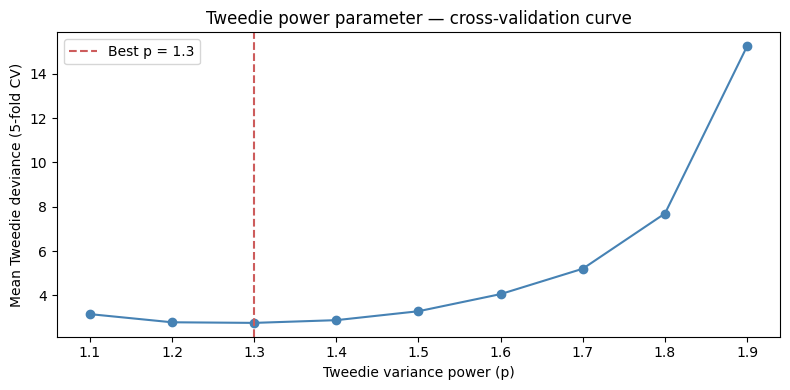

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(cv_deviances.keys()), list(cv_deviances.values()),
        marker='o', color='steelblue', linewidth=1.5)
ax.axvline(best_p, color='indianred', linestyle='--', label=f'Best p = {best_p}')
ax.set_xlabel("Tweedie variance power (p)")
ax.set_ylabel("Mean Tweedie deviance (5-fold CV)")
ax.set_title("Tweedie power parameter — cross-validation curve")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Final Model Training

We train the final model on the full training set using the best `p` from CV.
A 10% internal holdout (drawn from training, stratified on `y > 0`) is used
for early stopping only — it is never seen during evaluation.

We set `n_estimators=3000` with `early_stopping_rounds=75` so the model can grow
as large as needed while stopping before it overfits.

In [7]:
X_tr_f, X_es, y_tr_f, y_es = train_test_split(
    X_train, y_train,
    test_size=0.10,
    random_state=42,
    stratify=(y_train > 0).astype(int),
)

final_model = lgb.LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=best_p,
    num_leaves=63,
    min_child_samples=20,
    learning_rate=0.05,
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
final_model.fit(
    X_tr_f, y_tr_f,
    eval_set=[(X_es, y_es)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
print(f"\nFinal model stopped at iteration {final_model.best_iteration_}")

[100]	valid_0's tweedie: 3.73526

Final model stopped at iteration 41


In [8]:
import joblib
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / 'option1_tweedie.joblib'
joblib.dump({'model': final_model, 'best_p': best_p, 'feature_names': list(X.columns)}, MODEL_PATH)
print(f'Saved: {MODEL_PATH}')
print(f'  best_p       = {best_p}')
print(f'  best_iter    = {final_model.best_iteration_}')
print(f'  feature_names: {X.shape[1]} features')
print()
print('Load in another notebook with:')
print('  import joblib')
print(f'  obj = joblib.load("{MODEL_PATH}")')
print('  model, best_p, features = obj["model"], obj["best_p"], obj["feature_names"]')

Saved: models/option1_tweedie.joblib
  best_p       = 1.3
  best_iter    = 41
  feature_names: 37 features

Load in another notebook with:
  import joblib
  obj = joblib.load("models/option1_tweedie.joblib")
  model, best_p, features = obj["model"], obj["best_p"], obj["feature_names"]


## 6. Test Set Evaluation

We report four complementary metrics:

| Metric | What it measures |
|---|---|
| **Tweedie deviance** | Native loss — fit quality under the Tweedie distributional assumption |
| **MAE on log1p scale** | Average prediction error, robust to the Loudoun County outlier |
| **RMSE on log1p scale** | Error penalizing large mistakes more, still on log scale |
| **AUC (binary 'has DC')** | How well predicted values rank counties by presence vs. absence |

We deliberately avoid raw-scale RMSE/MAE — those metrics are dominated by Loudoun
County (700+ DCs) and would obscure performance on the other 99.9% of counties.

In [9]:
y_pred = np.maximum(final_model.predict(X_test), 1e-9)

tweedie_dev = mean_tweedie_deviance(y_test, y_pred, power=best_p)
mae_log     = mean_absolute_error(np.log1p(y_test), np.log1p(y_pred))
rmse_log    = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
auc         = roc_auc_score((y_test > 0).astype(int), y_pred)
median_ae   = float(np.median(np.abs(y_test - y_pred)))

print("=" * 50)
print(f"  Tweedie deviance (p={best_p}):  {tweedie_dev:.5f}")
print(f"  MAE  (log1p scale):            {mae_log:.4f}")
print(f"  RMSE (log1p scale):            {rmse_log:.4f}")
print(f"  AUC  (has any DC):             {auc:.4f}")
print(f"  Median AE (raw scale):         {median_ae:.3f}  data centers")
print("=" * 50)

  Tweedie deviance (p=1.3):  1.75550
  MAE  (log1p scale):            0.3120
  RMSE (log1p scale):            0.4736
  AUC  (has any DC):             0.8074
  Median AE (raw scale):         0.185  data centers


## 7. Diagnostic Plots

Two plots to check model calibration:
1. **Predicted vs. actual (log1p scale)** — ideally points scatter tightly around the diagonal.
   Blue = zero counties, red = non-zero counties.
2. **Residual plot** — residuals vs. predicted values. No systematic fan or curve = well-calibrated.

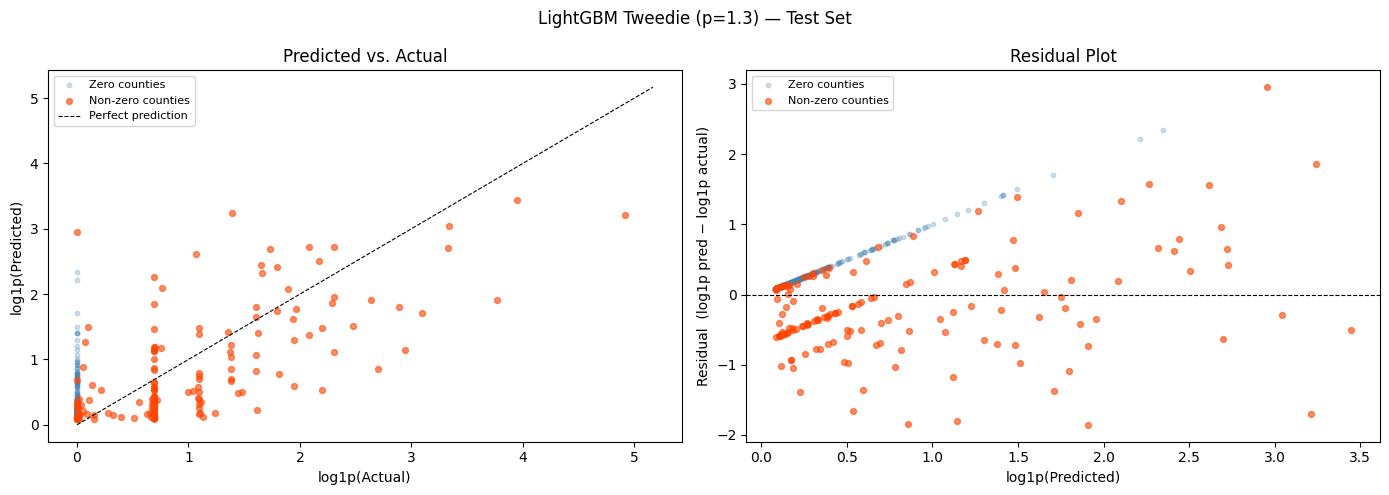

In [10]:
has_dc    = (y_test > 0).values
log_actual = np.log1p(y_test.values)
log_pred   = np.log1p(y_pred)
residuals  = log_pred - log_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
ax = axes[0]
ax.scatter(log_actual[~has_dc], log_pred[~has_dc],
           alpha=0.25, s=10, color='steelblue', label='Zero counties')
ax.scatter(log_actual[has_dc], log_pred[has_dc],
           alpha=0.6, s=18, color='orangered', label='Non-zero counties')
lim = max(log_actual.max(), log_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='Perfect prediction')
ax.set_xlabel("log1p(Actual)")
ax.set_ylabel("log1p(Predicted)")
ax.set_title("Predicted vs. Actual")
ax.legend(fontsize=8)

# Residuals
ax = axes[1]
ax.scatter(log_pred[~has_dc], residuals[~has_dc],
           alpha=0.25, s=10, color='steelblue', label='Zero counties')
ax.scatter(log_pred[has_dc], residuals[has_dc],
           alpha=0.6, s=18, color='orangered', label='Non-zero counties')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("log1p(Predicted)")
ax.set_ylabel("Residual  (log1p pred − log1p actual)")
ax.set_title("Residual Plot")
ax.legend(fontsize=8)

plt.suptitle(f"LightGBM Tweedie (p={best_p}) — Test Set", fontsize=12)
plt.tight_layout()
plt.show()

### Decile calibration

We bin the test set into deciles by predicted value and compare mean predicted vs. mean actual.
A well-calibrated model should track the diagonal — if it consistently over- or under-predicts
in certain deciles, that indicates systematic bias.

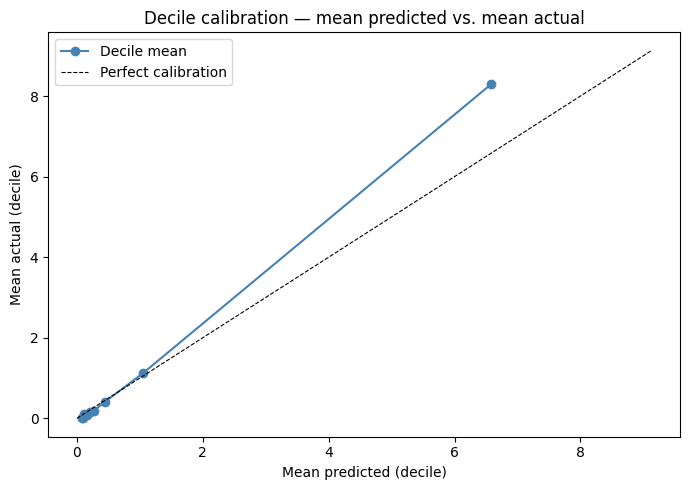

        actual   pred
decile               
0        0.019  0.089
1        0.000  0.099
2        0.107  0.113
3        0.088  0.131
4        0.071  0.159
5        0.157  0.202
6        0.194  0.273
7        0.410  0.446
8        1.123  1.052
9        8.296  6.583


In [11]:
calib = pd.DataFrame({"actual": y_test.values, "pred": y_pred})
calib["decile"] = pd.qcut(calib["pred"], q=10, labels=False, duplicates="drop")
decile_summary = calib.groupby("decile")[["actual", "pred"]].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(decile_summary["pred"], decile_summary["actual"],
        marker='o', color='steelblue', label='Decile mean')
ref_max = max(decile_summary["pred"].max(), decile_summary["actual"].max()) * 1.1
ax.plot([0, ref_max], [0, ref_max], 'k--', linewidth=0.8, label='Perfect calibration')
ax.set_xlabel("Mean predicted (decile)")
ax.set_ylabel("Mean actual (decile)")
ax.set_title("Decile calibration — mean predicted vs. mean actual")
ax.legend()
plt.tight_layout()
plt.show()

print(decile_summary.round(3).to_string())

## 8. Feature Importance & SHAP

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.
For LightGBM, we use the exact `TreeExplainer`, which is fast and exact (no sampling).

Since LightGBM Tweedie models `log(E[y|X])`, SHAP values are on the **log scale**:
a SHAP value of +1 for a feature means that feature contributes `exp(1) ≈ 2.7×` more
predicted data centers compared to the baseline (average prediction).

Two plots:
1. **Bar chart** — global feature importance by mean |SHAP|, showing which features matter most overall
2. **Beeswarm** — each dot is a county; color = feature value (red = high, blue = low);
   x-position = SHAP contribution. Shows both direction and magnitude.

In [12]:
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (628, 37)


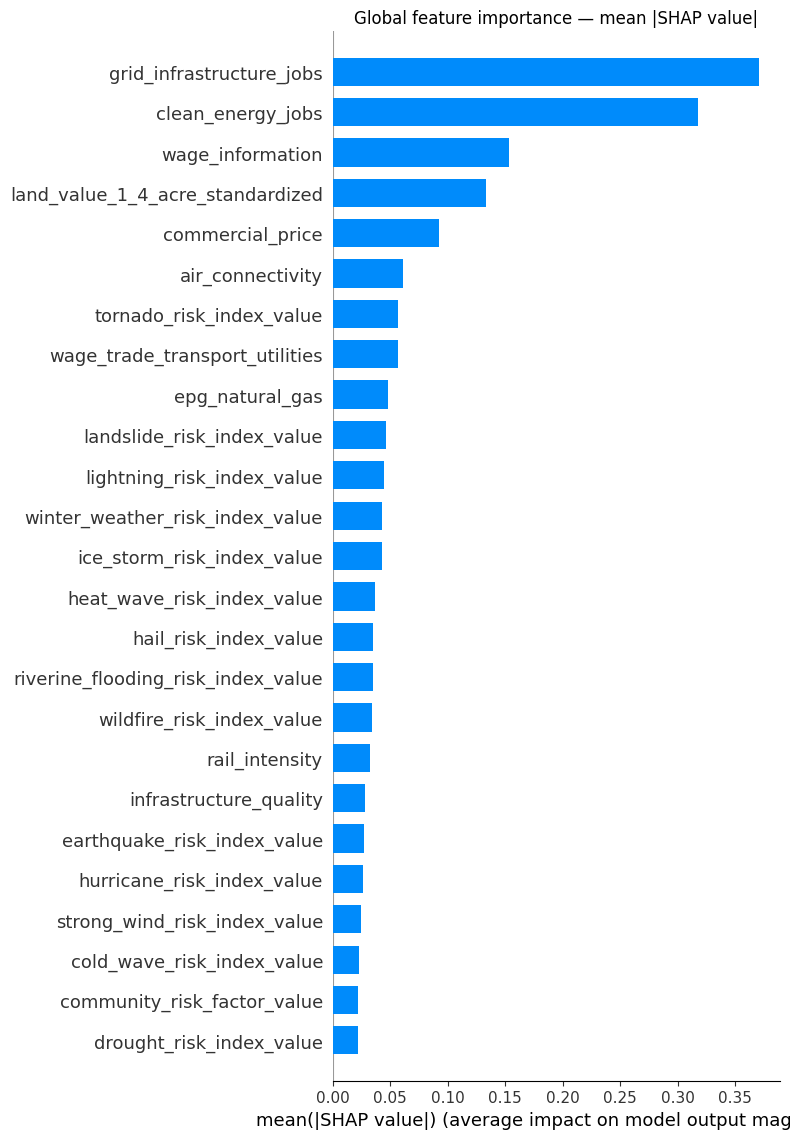

In [13]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  show=False, max_display=25)
plt.title("Global feature importance — mean |SHAP value|")
plt.tight_layout()
plt.show()

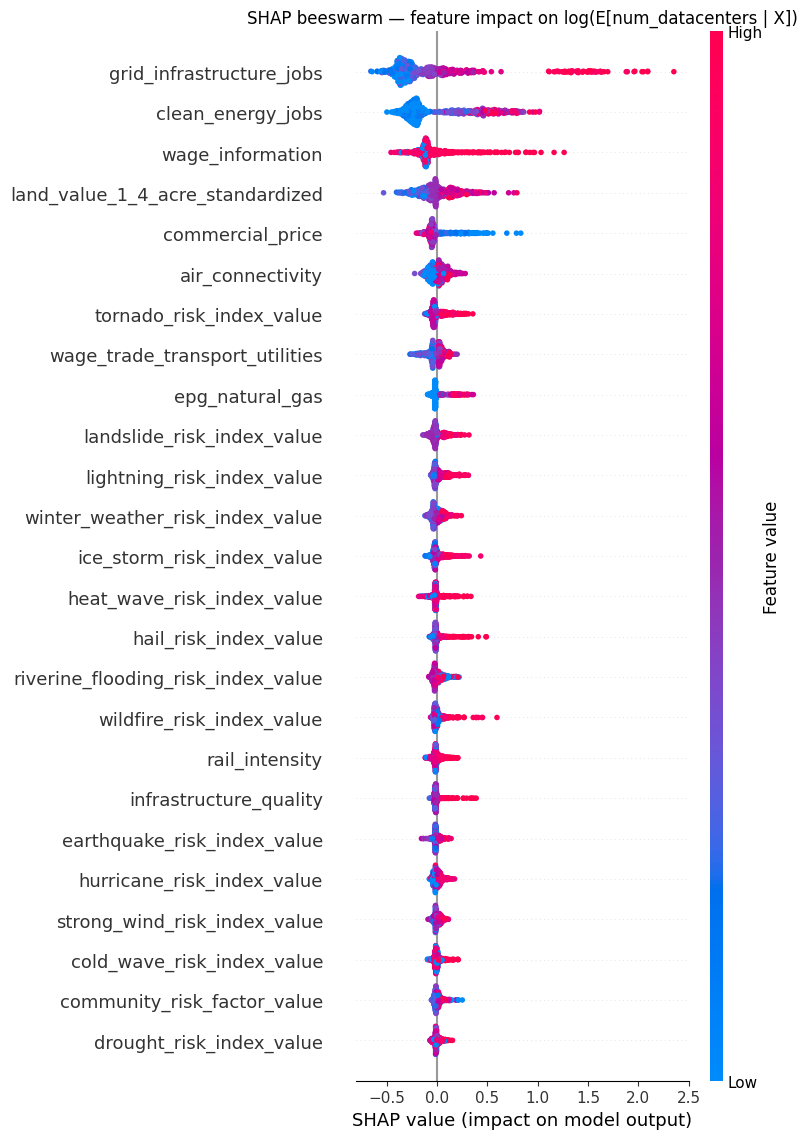

In [14]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=25)
plt.title("SHAP beeswarm — feature impact on log(E[num_datacenters | X])")
plt.tight_layout()
plt.show()

## 9. Summary

### Model
- **Architecture**: LightGBM gradient boosting with Tweedie objective
- **Target**: `num_datacenters` on original (untransformed) scale
- **Best `p`**: determined by 5-fold CV (see Section 4)
- **Features**: 37 structural features — `state` excluded deliberately (see Section 2)

### What the Tweedie model gives you
- A single model that simultaneously captures "does this county have any data center?"
  AND "how many if so?" — without needing a threshold or a second-stage model
- Predictions are always non-negative (log link ensures this)
- Zero-inflated counties naturally receive predictions close to (but not exactly) zero

### What it cannot do
- It cannot separate the drivers of **presence** from the drivers of **scale** — those
  SHAP effects are blended. Use Option 2 (two-part model) if that distinction matters.
- It does not produce an explicit probability of "has any DC" — but `y_pred` can be
  used as a score for ranking counties by attractiveness (higher = more likely/more DCs).

### Next step: Option 2
Build the two-part (hurdle) model in `modeling_option2_hurdle.ipynb` and compare
performance metrics and SHAP interpretations side by side.